In [10]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../results/annotation/annotated_candidates.tsv"

df = pd.read_csv(file_path, sep="\t")

print("Number of candidate variants:", len(df))

display(df)

Number of candidate variants: 5


,CHROM,POS,REF,ALT,QUAL,NORMAL_GT,NORMAL_AD,TUMOUR_GT,TUMOUR_AD,NORMAL_DP,...,TUMOUR_ALT_READS,TUMOUR_VAF,GENE,GENE_ID,TRANSCRIPT,CONSEQUENCE,HGVSC,HGVSP,AMINO_ACIDS,PROTEIN_POSITION
0,17,7011019,C,G,118.670,0/0,"25,0",0/1,"25,12",25,...,12,0.324324,ASGR2,ENSG00000161944,ENST00000380952,intron_variant,ENST00000380952.2:c.424+136G>C,NaN,NaN,NaN
1,17,7482930,T,G,183.008,0/0,"87,3",1/1,"0,10",90,...,10,1.000000,CD68,ENSG00000129226,ENST00000250092,5_prime_UTR_variant,ENST00000250092.6:c.-66T>G,NaN,NaN,NaN
2,17,7491818,G,C,220.849,0/0,"85,0",0/1,"40,100",85,...,100,0.714286,SOX15,ENSG00000129194,ENST00000250055,missense_variant,ENST00000250055.2:c.580C>G,ENSP00000355354.2:p.Gln194Glu,Q/E,194.0
3,17,7578406,C,T,216.008,0/0,"67,1",1/1,"1,86",68,...,86,0.988506,TP53,ENSG00000141510,ENST00000269305,missense_variant,ENST00000269305.4:c.524G>A,ENSP00000269305.4:p.Arg175His,R/H,175.0
4,17,7710987,C,G,216.008,0/0,"17,0",1/1,"0,28",17,...,28,1.000000,DNAH2,ENSG00000183914,ENST00000572933,intron_variant,ENST00000572933.1:c.9729+83C>G,NaN,NaN,NaN


In [11]:
# Keep the most useful columns for interpretation

summary = df[
    [
        "CHROM",
        "POS",
        "REF",
        "ALT",
        "QUAL",
        "NORMAL_VAF",
        "TUMOUR_VAF",
        "GENE",
        "CONSEQUENCE",
        "HGVSC",
        "HGVSP"
    ]
].copy()

display(summary)

,CHROM,POS,REF,ALT,QUAL,NORMAL_VAF,TUMOUR_VAF,GENE,CONSEQUENCE,HGVSC,HGVSP
0,17,7011019,C,G,118.670,0.000000,0.324324,ASGR2,intron_variant,ENST00000380952.2:c.424+136G>C,NaN
1,17,7482930,T,G,183.008,0.033333,1.000000,CD68,5_prime_UTR_variant,ENST00000250092.6:c.-66T>G,NaN
2,17,7491818,G,C,220.849,0.000000,0.714286,SOX15,missense_variant,ENST00000250055.2:c.580C>G,ENSP00000355354.2:p.Gln194Glu
3,17,7578406,C,T,216.008,0.014706,0.988506,TP53,missense_variant,ENST00000269305.4:c.524G>A,ENSP00000269305.4:p.Arg175His
4,17,7710987,C,G,216.008,0.000000,1.000000,DNAH2,intron_variant,ENST00000572933.1:c.9729+83C>G,NaN


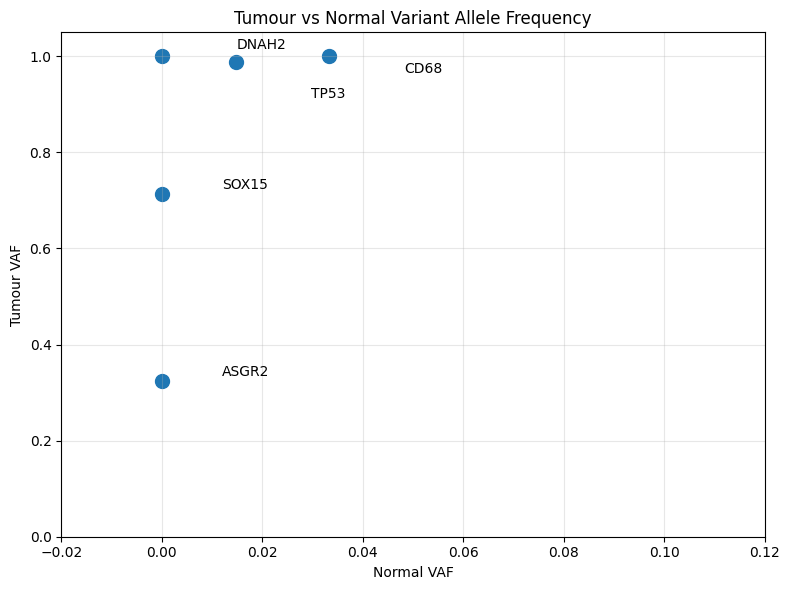

In [12]:
# Compare variant allele frequency (VAF) between normal and tumour samples

plt.figure(figsize=(8, 6))

plt.scatter(
    summary["NORMAL_VAF"],
    summary["TUMOUR_VAF"],
    s=100
)

# Custom label positions to avoid overlap
offsets = {
    "ASGR2": (0.012, 0.01),
    "SOX15": (0.012, 0.01),
    "CD68": (0.015, -0.035),
    "TP53": (0.015, -0.075),
    "DNAH2": (0.015, 0.015)
}

for _, row in summary.iterrows():

    dx, dy = offsets.get(row["GENE"], (0.01, 0.01))

    plt.text(
        row["NORMAL_VAF"] + dx,
        row["TUMOUR_VAF"] + dy,
        row["GENE"],
        fontsize=10
    )

plt.xlabel("Normal VAF")
plt.ylabel("Tumour VAF")
plt.title("Tumour vs Normal Variant Allele Frequency")

plt.xlim(-0.02, 0.12)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/vaf_normal_vs_tumour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

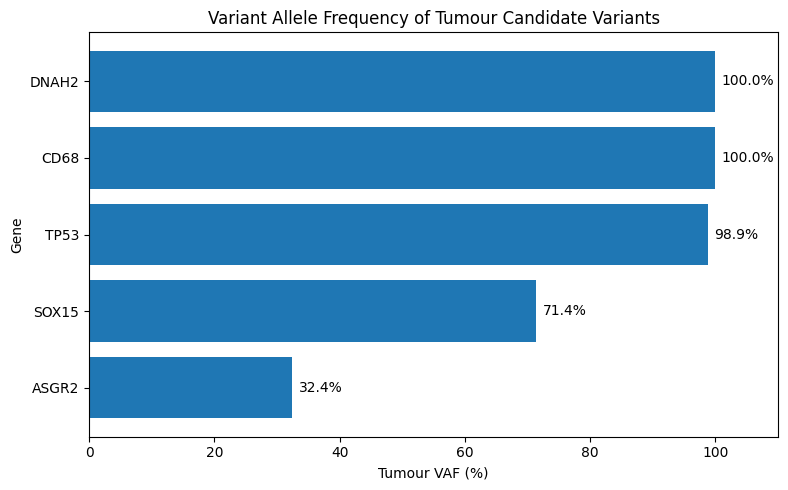

In [13]:
# Tumour VAF for each candidate gene

plot_df = summary.sort_values(
    "TUMOUR_VAF",
    ascending=True
).copy()

plt.figure(figsize=(8, 5))

bars = plt.barh(
    plot_df["GENE"],
    plot_df["TUMOUR_VAF"] * 100
)

# Add percentage labels
for bar, value in zip(bars, plot_df["TUMOUR_VAF"] * 100):
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.xlabel("Tumour VAF (%)")
plt.ylabel("Gene")

plt.title(
    "Variant Allele Frequency of Tumour Candidate Variants"
)

plt.xlim(0, 110)

plt.tight_layout()

plt.savefig(
    "../figures/tumour_vaf_by_gene.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

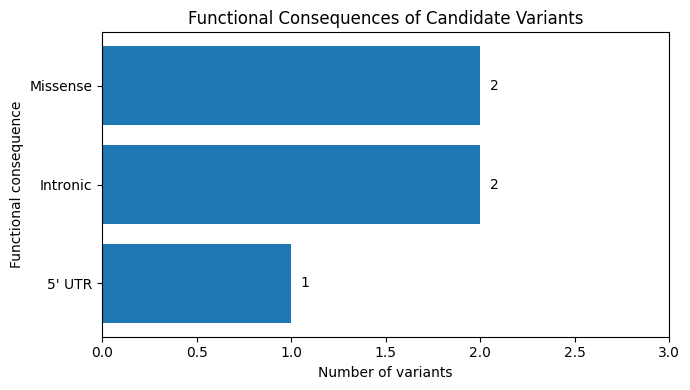

In [14]:
# Count functional consequences

consequence_counts = summary["CONSEQUENCE"].value_counts()

# Cleaner labels for the figure
clean_labels = {
    "missense_variant": "Missense",
    "intron_variant": "Intronic",
    "5_prime_UTR_variant": "5' UTR"
}

consequence_counts.index = [
    clean_labels.get(x, x)
    for x in consequence_counts.index
]

consequence_counts = consequence_counts.sort_values()

plt.figure(figsize=(7, 4))

bars = plt.barh(
    consequence_counts.index,
    consequence_counts.values
)

for bar, value in zip(bars, consequence_counts.values):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center"
    )

plt.xlabel("Number of variants")
plt.ylabel("Functional consequence")
plt.title("Functional Consequences of Candidate Variants")

plt.xlim(0, consequence_counts.max() + 1)

plt.tight_layout()

plt.savefig(
    "../figures/variant_consequences.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# Final biological summary

final_results = summary[
    [
        "CHROM",
        "POS",
        "REF",
        "ALT",
        "GENE",
        "CONSEQUENCE",
        "NORMAL_VAF",
        "TUMOUR_VAF",
        "HGVSC",
        "HGVSP"
    ]
].copy()

# Convert VAF to percentages
final_results["NORMAL_VAF_PERCENT"] = (
    final_results["NORMAL_VAF"] * 100
).round(1)

final_results["TUMOUR_VAF_PERCENT"] = (
    final_results["TUMOUR_VAF"] * 100
).round(1)

# Remove old decimal VAF columns
final_results = final_results.drop(
    columns=["NORMAL_VAF", "TUMOUR_VAF"]
)

display(final_results)

,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,HGVSC,HGVSP,NORMAL_VAF_PERCENT,TUMOUR_VAF_PERCENT
0,17,7011019,C,G,ASGR2,intron_variant,ENST00000380952.2:c.424+136G>C,NaN,0.0,32.4
1,17,7482930,T,G,CD68,5_prime_UTR_variant,ENST00000250092.6:c.-66T>G,NaN,3.3,100.0
2,17,7491818,G,C,SOX15,missense_variant,ENST00000250055.2:c.580C>G,ENSP00000355354.2:p.Gln194Glu,0.0,71.4
3,17,7578406,C,T,TP53,missense_variant,ENST00000269305.4:c.524G>A,ENSP00000269305.4:p.Arg175His,1.5,98.9
4,17,7710987,C,G,DNAH2,intron_variant,ENST00000572933.1:c.9729+83C>G,NaN,0.0,100.0


In [16]:
final_results.to_csv(
    "../results/annotation/final_candidate_summary.tsv",
    sep="\t",
    index=False
)

print("Final results saved.")

Final results saved.
